# Superstore Profit Prediction and Discount Analysis
## Overfitting-Controlled Regression Project

**Objective:** Predict order-line `Profit` from `Sales`, `Discount`, `Category`, and `Region`, analyse discount-related losses, and provide a reusable prediction function.

### Overfitting controls
1. Separate training, validation, and untouched final-test sets.
2. Profit-quantile stratification to distribute extreme gains and losses across splits.
3. Cross-validation performed only inside the training set.
4. Cost-complexity pruning (`ccp_alpha`) for the Decision Tree.
5. Depth, leaf-size, feature-sampling, and bootstrap-row constraints for Random Forest.
6. Train–validation–test metrics, generalization-gap checks, and learning curves.

> `ProfitMargin = Profit / Sales` is calculated for descriptive analysis only. It is excluded from model inputs because it directly contains the target and would cause leakage.

In [1]:
# Run once if required:
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy joblib

import sqlite3
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

## 1. Load and inspect the dataset

Place `Sample - Superstore.csv` in the same folder as this notebook when running locally.

In [2]:
df = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding="latin1")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.0000,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.0000,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.0000,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.4500,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.2000,2.5164


In [4]:
required_columns = [
    'Sales', 'Quantity', 'Discount', 'Profit', 'Category',
    'Sub-Category', 'Region', 'Segment'
]
missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

quality_summary = pd.DataFrame({
    'Data type': df[required_columns].dtypes.astype(str),
    'Missing values': df[required_columns].isna().sum(),
    'Unique values': df[required_columns].nunique(),
})
display(quality_summary)
display(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().T)

,Data type,Missing values,Unique values
Sales,float64,0,5825
Quantity,int64,0,14
Discount,float64,0,12
Profit,float64,0,7287
Category,object,0,3
Sub-Category,object,0,17
Region,object,0,4
Segment,object,0,3


,count,mean,std,min,25%,50%,75%,max
Sales,"9,994.0000",229.8580,623.2451,0.4440,17.2800,54.4900,209.9400,"22,638.4800"
Quantity,"9,994.0000",3.7896,2.2251,1.0000,2.0000,3.0000,5.0000,14.0000
Discount,"9,994.0000",0.1562,0.2065,0.0000,0.0000,0.2000,0.2000,0.8000
Profit,"9,994.0000",28.6569,234.2601,"-6,599.9780",1.7288,8.6665,29.3640,"8,399.9760"


## 2. SQL questions

The dataset is copied into an in-memory SQLite table named `orders`.

In [5]:
connection = sqlite3.connect(':memory:')
df.to_sql('orders', connection, index=False, if_exists='replace')

def run_sql(query):
    result = pd.read_sql_query(query, connection)
    display(result)
    return result

In [6]:
# Q1. Total Sales and Profit grouped by Region
q1 = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM orders
GROUP BY Region
ORDER BY Total_Profit DESC;
"""
region_sales_profit = run_sql(q1)

,Region,Total_Sales,Total_Profit
0,West,"725,457.8200","108,418.4500"
1,East,"678,781.2400","91,522.7800"
2,South,"391,721.9100","46,749.4300"
3,Central,"501,239.8900","39,706.3600"


In [7]:
# Q2. Total Profit grouped by Category
q2 = """
SELECT
    Category,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM orders
GROUP BY Category
ORDER BY Total_Profit DESC;
"""
category_profit = run_sql(q2)

,Category,Total_Profit
0,Technology,"145,454.9500"
1,Office Supplies,"122,490.8000"
2,Furniture,"18,451.2700"


In [8]:
# Q3. Sub-categories where average Profit is negative
q3 = """
SELECT
    "Sub-Category" AS Sub_Category,
    ROUND(AVG(Profit), 2) AS Average_Profit,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(*) AS Order_Lines
FROM orders
GROUP BY "Sub-Category"
HAVING AVG(Profit) < 0
ORDER BY Average_Profit ASC;
"""
negative_subcategories = run_sql(q3)

,Sub_Category,Average_Profit,Total_Profit,Order_Lines
0,Tables,-55.5700,"-17,725.4800",319
1,Bookcases,-15.2300,"-3,472.5600",228
2,Supplies,-6.2600,"-1,189.1000",190


In [9]:
# Q4. Average Discount grouped by Category
q4 = """
SELECT
    Category,
    ROUND(AVG(Discount), 4) AS Average_Discount
FROM orders
GROUP BY Category
ORDER BY Average_Discount DESC;
"""
category_discount = run_sql(q4)

,Category,Average_Discount
0,Furniture,0.1739
1,Office Supplies,0.1573
2,Technology,0.1323


In [10]:
# Q5. Orders with Profit below the overall average Profit, using a subquery
q5 = """
SELECT *
FROM orders
WHERE Profit < (SELECT AVG(Profit) FROM orders)
ORDER BY Profit ASC;
"""
below_average_profit = pd.read_sql_query(q5, connection)
print(f'Overall average Profit: ${df.Profit.mean():,.2f}')
print(f'Rows below overall average: {len(below_average_profit):,}')
display(below_average_profit.head(10))

Overall average Profit: $28.66
Rows below overall average: 7,443


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,7773,CA-2016-108196,11/25/2016,12/2/2016,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,Ohio,43130,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,"4,499.9850",5,0.7000,"-6,599.9780"
1,684,US-2017-168116,11/4/2017,11/4/2017,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,North Carolina,27217,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,"7,999.9800",4,0.5000,"-3,839.9904"
2,9775,CA-2014-169019,7/26/2014,7/30/2014,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,Texas,78207,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,"2,177.5840",8,0.8000,"-3,701.8928"
3,3012,CA-2017-134845,4/17/2017,4/23/2017,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,Colorado,80027,West,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,"2,549.9850",5,0.7000,"-3,399.9800"
4,4992,US-2017-122714,12/7/2017,12/13/2017,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,Illinois,60653,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,"1,889.9900",5,0.8000,"-2,929.4845"
5,3152,CA-2015-147830,12/15/2015,12/18/2015,First Class,NF-18385,Natalie Fritzler,Consumer,United States,Newark,Ohio,43055,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,"1,799.9940",2,0.7000,"-2,639.9912"
6,5311,CA-2017-131254,11/19/2017,11/21/2017,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,Texas,77095,Central,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,"1,525.1880",6,0.8000,"-2,287.7820"
7,9640,CA-2015-116638,1/28/2015,1/31/2015,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,North Carolina,28027,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,"4,297.6440",13,0.4000,"-1,862.3124"
8,1200,CA-2016-130946,4/8/2016,4/12/2016,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,Texas,77041,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,"1,088.7920",4,0.8000,"-1,850.9464"
9,2698,CA-2014-145317,3/18/2014,3/23/2014,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,"22,638.4800",6,0.5000,"-1,811.0784"


## 3. Exploratory Data Analysis with Seaborn

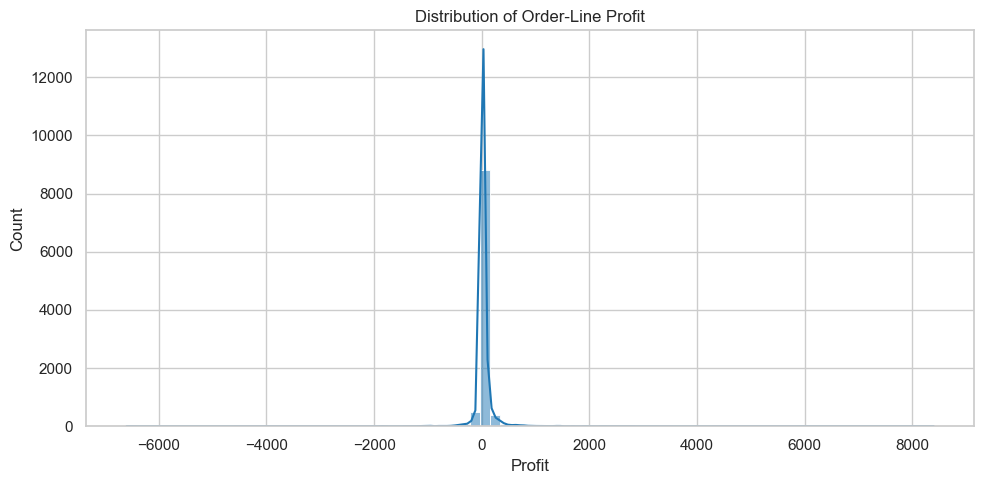

**Observation:** Profit is strongly right-skewed (skewness = 7.56). The median Profit is $8.67; extreme gains and losses produce a long-tailed distribution.

In [11]:
# Chart 1: Profit distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Profit', bins=80, kde=True, color='tab:blue')
plt.title('Distribution of Order-Line Profit')
plt.xlabel('Profit')
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Observation:** Profit is strongly right-skewed (skewness = {df['Profit'].skew():.2f}). "
    f"The median Profit is ${df['Profit'].median():,.2f}; extreme gains and losses produce a long-tailed distribution."
))

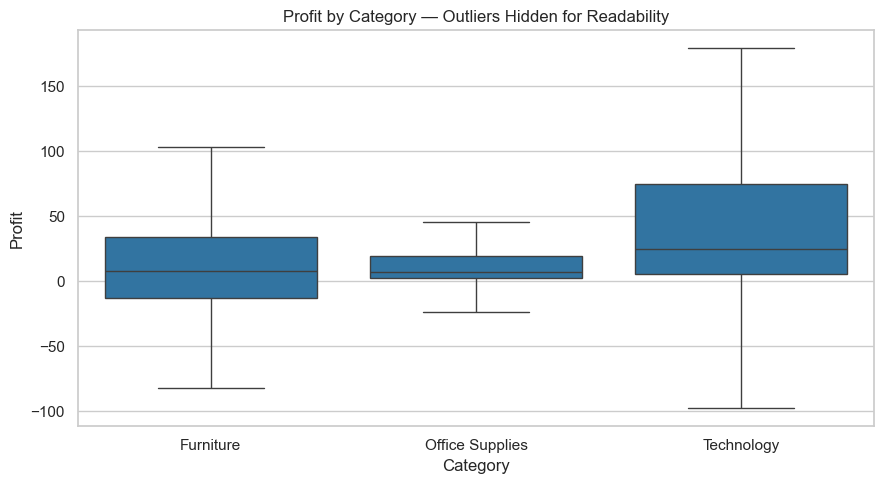

**Observation:** **Furniture** has the lowest total Profit and a weaker Profit distribution than the other categories.

In [12]:
# Chart 2: Profit by Category
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Category', y='Profit', showfliers=False, color='tab:blue')
plt.title('Profit by Category — Outliers Hidden for Readability')
plt.tight_layout()
plt.show()

category_stats = df.groupby('Category')['Profit'].agg(['mean', 'median', 'sum'])
least_profitable_category = category_stats['sum'].idxmin()
display(Markdown(
    f"**Observation:** **{least_profitable_category}** has the lowest total Profit and a weaker Profit distribution than the other categories."
))

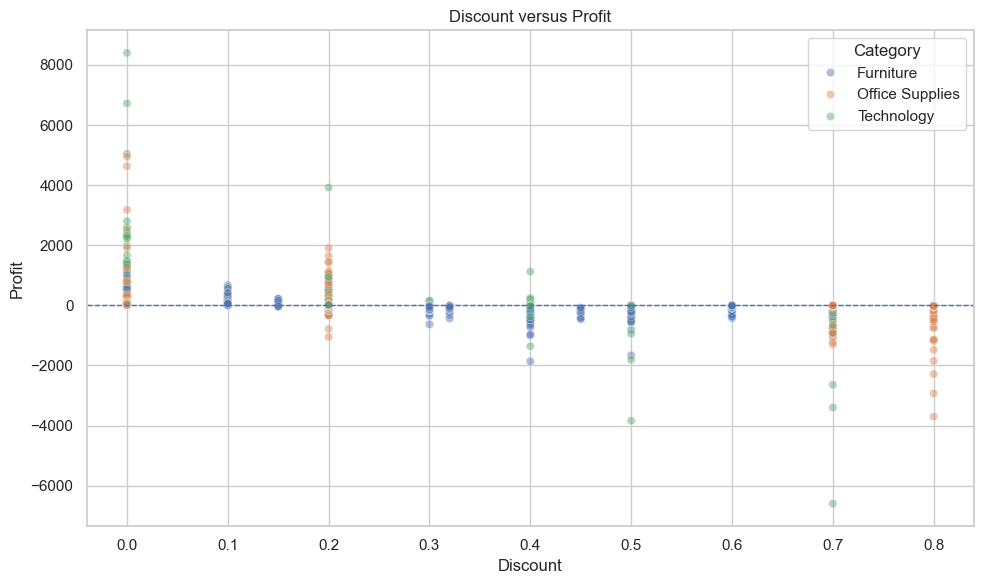

**Observation:** Discount and Profit have a negative correlation of -0.219. High-discount observations are concentrated more heavily in the loss-making area.

In [13]:
# Chart 3: Discount versus Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.45, palette='deep')
plt.axhline(0, linestyle='--', linewidth=1)
plt.title('Discount versus Profit')
plt.tight_layout()
plt.show()

corr_discount_profit = df[['Discount', 'Profit']].corr().iloc[0, 1]
display(Markdown(
    f"**Observation:** Discount and Profit have a negative correlation of {corr_discount_profit:.3f}. "
    "High-discount observations are concentrated more heavily in the loss-making area."
))

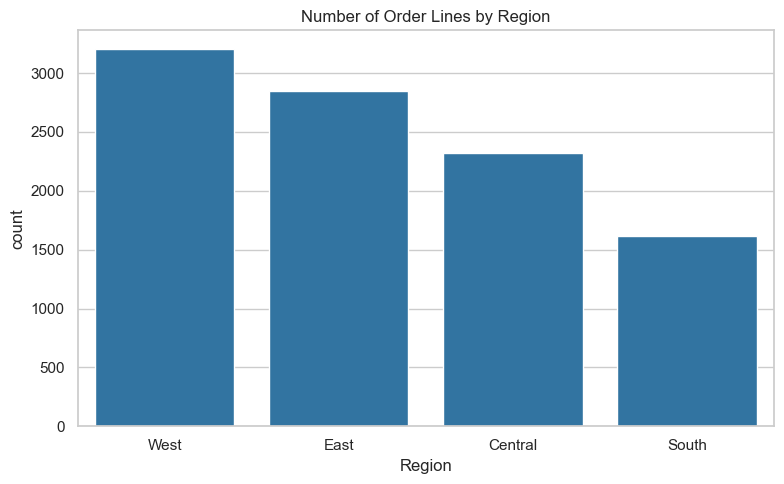

**Observation:** West has the most order lines (3,203), whereas South has the fewest (1,620).

In [15]:
# Chart 4: Region countplot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Region', order=df['Region'].value_counts().index, color='tab:blue')
plt.title('Number of Order Lines by Region')
plt.tight_layout()
plt.show()

region_counts = df['Region'].value_counts()
display(Markdown(
    f"**Observation:** {region_counts.index[0]} has the most order lines ({region_counts.iloc[0]:,}), "
    f"whereas {region_counts.index[-1]} has the fewest ({region_counts.iloc[-1]:,})."
))

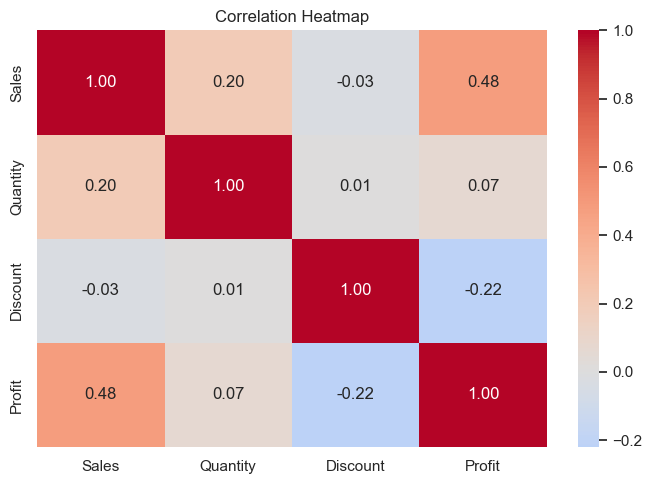

**Observation:** Sales has the strongest positive linear relationship with Profit. Discount is negatively associated with Profit, while Quantity is only weakly associated.

In [16]:
# Chart 5: Correlation heatmap
numeric_for_corr = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df[numeric_for_corr].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

display(Markdown(
    "**Observation:** Sales has the strongest positive linear relationship with Profit. "
    "Discount is negatively associated with Profit, while Quantity is only weakly associated."
))

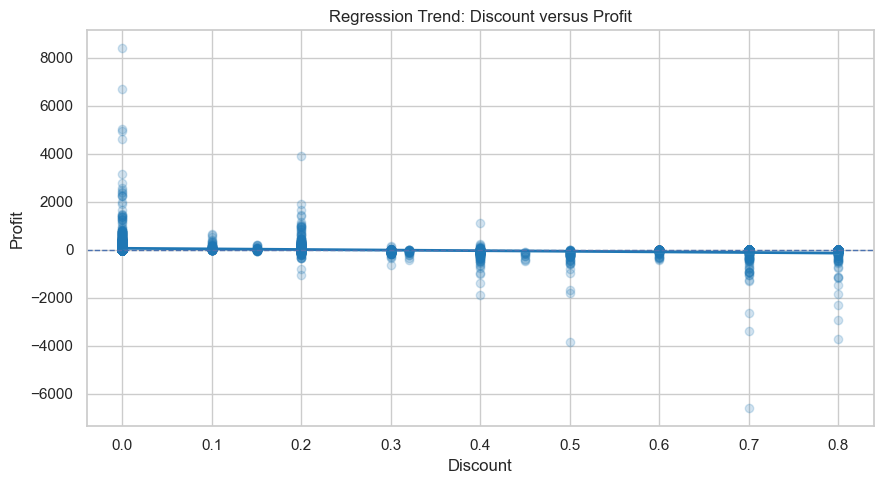

**Observation:** The fitted line slopes downward, confirming that larger discounts generally reduce Profit. The wide spread indicates that product and cost characteristics also matter.

In [17]:
# Chart 6: Regression trend for Discount versus Profit
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df, x='Discount', y='Profit',
    scatter_kws={'alpha': 0.20},
    line_kws={'linewidth': 2}, color='tab:blue',
)
plt.axhline(0, linestyle='--', linewidth=1)
plt.title('Regression Trend: Discount versus Profit')
plt.tight_layout()
plt.show()

display(Markdown(
    "**Observation:** The fitted line slopes downward, confirming that larger discounts generally reduce Profit. "
    "The wide spread indicates that product and cost characteristics also matter."
))

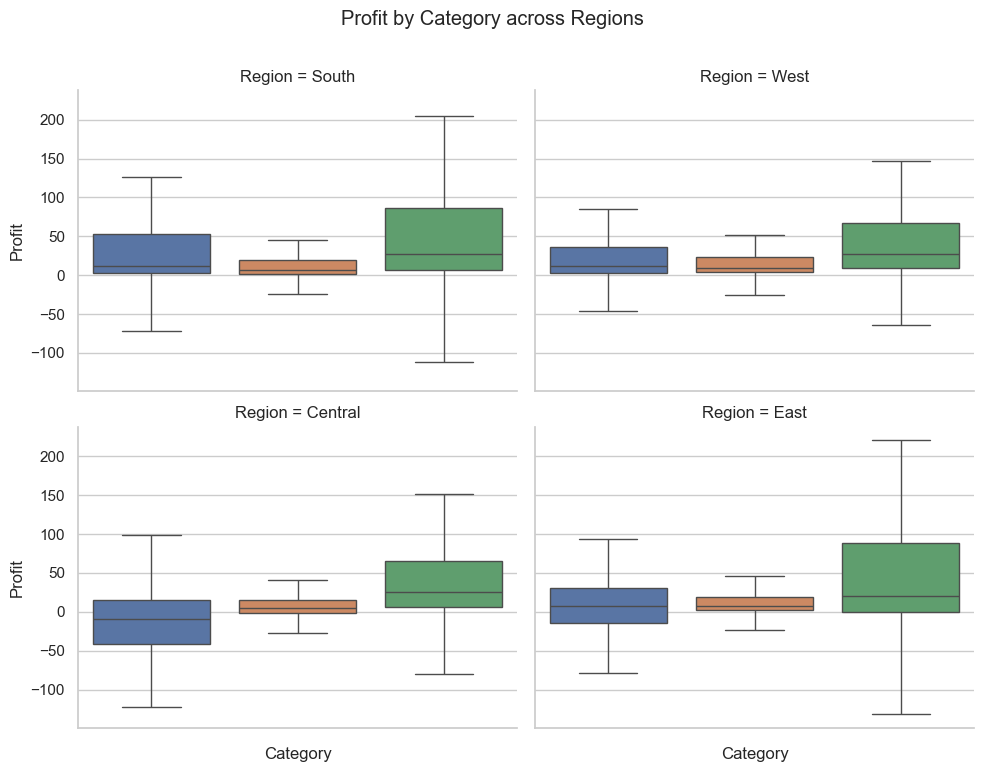

**Observation:** Furniture remains comparatively weak in several regions, so its profitability problem is not restricted to one market.

In [18]:
# Chart 7: Faceted boxplot by Category and Region
facet = sns.catplot(
    data=df,
    x='Category', y='Profit', col='Region',
    kind='box', showfliers=False,
    col_wrap=2, height=4, aspect=1.25, palette='deep',
)
facet.set_xticklabels(rotation=20)
facet.fig.subplots_adjust(top=0.88)
facet.fig.suptitle('Profit by Category across Regions')
plt.show()

display(Markdown(
    "**Observation:** Furniture remains comparatively weak in several regions, so its profitability problem is not restricted to one market."
))

## 4. Feature engineering

The model receives the four required deployment inputs. Leakage-free derived predictors are calculated from them:

- `DiscountAmount = Sales × Discount`
- `NetSales = Sales × (1 − Discount)`
- `LogSales = log(1 + Sales)`
- `HighDiscount = 1` for Discount ≥ 30%

In [19]:
# Descriptive feature only; never use it to predict Profit.
df['ProfitMargin'] = np.where(df['Sales'].ne(0), df['Profit'] / df['Sales'], np.nan)

def engineer_features(data):
    """Create leakage-free predictors from the four prototype inputs."""
    data = data.copy()
    required = ['Sales', 'Discount', 'Category', 'Region']
    missing = [c for c in required if c not in data.columns]
    if missing:
        raise ValueError(f'Missing predictor columns: {missing}')

    data['DiscountAmount'] = data['Sales'] * data['Discount']
    data['NetSales'] = data['Sales'] * (1 - data['Discount'])
    data['LogSales'] = np.log1p(data['Sales'].clip(lower=0))
    data['HighDiscount'] = (data['Discount'] >= 0.30).astype(int)
    return data

raw_feature_columns = ['Sales', 'Discount', 'Category', 'Region']
X_raw = df[raw_feature_columns].copy()
X = engineer_features(X_raw)
y = df['Profit'].copy()

print('Model columns:', X.columns.tolist())
print('ProfitMargin used as a predictor?', 'ProfitMargin' in X.columns)

Model columns: ['Sales', 'Discount', 'Category', 'Region', 'DiscountAmount', 'NetSales', 'LogSales', 'HighDiscount']
ProfitMargin used as a predictor? False


## 5. Training, validation, and untouched final-test split

Rank-based Profit quantile bins are used only to balance the split. Continuous Profit remains the regression target.

In [20]:
profit_bins = pd.qcut(y.rank(method='first'), q=10, labels=False)

# 85% development data and 15% untouched final test data
X_dev, X_test, y_dev, y_test, bins_dev, bins_test = train_test_split(
    X, y, profit_bins,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=profit_bins,
)

# Approximately 70% training and 15% validation overall
validation_fraction_of_dev = 0.15 / 0.85
X_train, X_val, y_train, y_val, bins_train, bins_val = train_test_split(
    X_dev, y_dev, bins_dev,
    test_size=validation_fraction_of_dev,
    random_state=RANDOM_STATE,
    stratify=bins_dev,
)

split_summary = pd.DataFrame({
    'Rows': [len(X_train), len(X_val), len(X_test)],
    'Profit mean': [y_train.mean(), y_val.mean(), y_test.mean()],
    'Profit median': [y_train.median(), y_val.median(), y_test.median()],
    'Profit std': [y_train.std(), y_val.std(), y_test.std()],
}, index=['Training', 'Validation', 'Final test'])
display(split_summary)

,Rows,Profit mean,Profit median,Profit std
Training,6995,26.9086,8.6715,238.7429
Validation,1499,37.9891,8.6436,269.5301
Final test,1500,27.4837,8.6535,164.9188


## 6. Preprocessing pipelines

In [21]:
numeric_features = [
    'Sales', 'Discount', 'DiscountAmount',
    'NetSales', 'LogSales', 'HighDiscount'
]
categorical_features = ['Category', 'Region']

numeric_linear = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
numeric_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

linear_preprocessor = ColumnTransformer([
    ('numeric', numeric_linear, numeric_features),
    ('categorical', categorical_transformer, categorical_features),
])
tree_preprocessor = ColumnTransformer([
    ('numeric', numeric_tree, numeric_features),
    ('categorical', categorical_transformer, categorical_features),
])

## 7. Evaluation and overfitting diagnostics

In [22]:
def regression_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
    }


def evaluate_three_splits(model, model_name):
    rows = []
    for split_name, X_part, y_part in [
        ('Train', X_train, y_train),
        ('Validation', X_val, y_val),
        ('Final Test', X_test, y_test),
    ]:
        metrics = regression_metrics(y_part, model.predict(X_part))
        rows.append({'Model': model_name, 'Split': split_name, **metrics})
    return pd.DataFrame(rows)


def overfit_diagnosis(result_table):
    train = result_table[result_table['Split'].eq('Train')].iloc[0]
    validation = result_table[result_table['Split'].eq('Validation')].iloc[0]
    r2_gap = train['R2'] - validation['R2']
    mae_ratio = validation['MAE'] / train['MAE'] if train['MAE'] else np.inf

    if r2_gap <= 0.15 and mae_ratio <= 1.30:
        status = 'Stable / no strong overfitting signal'
    elif r2_gap <= 0.25 and mae_ratio <= 1.50:
        status = 'Mild generalization gap'
    else:
        status = 'Potential overfitting — regularize further'

    return pd.DataFrame([{
        'Train–Validation R2 Gap': r2_gap,
        'Validation/Train MAE Ratio': mae_ratio,
        'Diagnosis': status,
    }])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv5_splits = list(cv5.split(X_train, bins_train))
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv3_splits = list(cv3.split(X_train, bins_train))

## 8. Model 1 — Linear Regression baseline

In [23]:
linear_model = Pipeline([
    ('preprocessor', linear_preprocessor),
    ('model', LinearRegression()),
])
linear_model.fit(X_train, y_train)
linear_results = evaluate_three_splits(linear_model, 'Linear Regression')
display(linear_results)
display(overfit_diagnosis(linear_results))

,Model,Split,R2,MAE,RMSE
0,Linear Regression,Train,0.7114,42.3106,128.2360
1,Linear Regression,Validation,0.9072,38.3055,82.0792
2,Linear Regression,Final Test,0.5495,40.4375,110.6571


,Train–Validation R2 Gap,Validation/Train MAE Ratio,Diagnosis
0,-0.1958,0.9053,Stable / no strong overfitting signal


## 9. Model 2 — Pruned Decision Tree

`cost_complexity_pruning_path` generates candidate `ccp_alpha` values. Cross-validation jointly tunes pruning and structural constraints.

In [24]:
X_train_tree = tree_preprocessor.fit_transform(X_train)
pruning_probe = DecisionTreeRegressor(random_state=RANDOM_STATE)
pruning_path = pruning_probe.cost_complexity_pruning_path(X_train_tree, y_train)
positive_alphas = np.unique(pruning_path.ccp_alphas[pruning_path.ccp_alphas >= 0])

if len(positive_alphas) > 20:
    alpha_indices = np.linspace(0, len(positive_alphas) - 2, 20).astype(int)
    alpha_candidates = np.unique(positive_alphas[alpha_indices])
else:
    alpha_candidates = positive_alphas

alpha_candidates = alpha_candidates[
    alpha_candidates <= np.quantile(positive_alphas, 0.95)
]
alpha_candidates = np.unique(np.append(alpha_candidates, 0.0))
print(f'Number of candidate ccp_alpha values: {len(alpha_candidates)}')
print(np.round(alpha_candidates, 6))

Number of candidate ccp_alpha values: 19
[0.00000e+00 0.00000e+00 2.00000e-06 7.00000e-06 2.00000e-05 5.00000e-05
 1.08000e-04 2.27000e-04 4.71000e-04 9.61000e-04 1.93300e-03 3.76200e-03
 6.99500e-03 1.37940e-02 2.82120e-02 5.96530e-02 1.32995e-01 4.02579e-01
 1.63201e+00]


In [25]:
decision_tree_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

tree_parameter_distributions = {
    'model__max_depth': [3, 4, 5, 6, 8, 10, 12, None],
    'model__min_samples_split': [10, 20, 30, 50, 75, 100],
    'model__min_samples_leaf': [5, 10, 15, 20, 30, 40, 60],
    'model__max_features': [None, 'sqrt', 'log2', 0.70],
    'model__ccp_alpha': alpha_candidates,
}

pruned_tree_search = RandomizedSearchCV(
    estimator=decision_tree_pipeline,
    param_distributions=tree_parameter_distributions,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv5_splits,
    random_state=RANDOM_STATE,
    n_jobs=2,
    return_train_score=True,
)
pruned_tree_search.fit(X_train, y_train)
pruned_tree = pruned_tree_search.best_estimator_

print('Best pruned-tree parameters:')
print(pruned_tree_search.best_params_)
print(f"Best cross-validated MAE: ${-pruned_tree_search.best_score_:,.2f}")

tree_results = evaluate_three_splits(pruned_tree, 'Pruned Decision Tree')
display(tree_results)
display(overfit_diagnosis(tree_results))

Best pruned-tree parameters:
{'model__min_samples_split': 50, 'model__min_samples_leaf': 5, 'model__max_features': None, 'model__max_depth': 12, 'model__ccp_alpha': np.float64(0.003762356810292437)}
Best cross-validated MAE: $32.80


,Model,Split,R2,MAE,RMSE
0,Pruned Decision Tree,Train,0.6605,27.3872,139.0954
1,Pruned Decision Tree,Validation,0.6833,30.7468,151.6375
2,Pruned Decision Tree,Final Test,0.6623,27.2455,95.8011


,Train–Validation R2 Gap,Validation/Train MAE Ratio,Diagnosis
0,-0.0228,1.1227,Stable / no strong overfitting signal


In [26]:
# Demonstrate why pruning is needed
unpruned_tree = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE)),
])
unpruned_tree.fit(X_train, y_train)

pruning_comparison = pd.DataFrame([
    {
        'Tree': 'Unpruned',
        'Train R2': r2_score(y_train, unpruned_tree.predict(X_train)),
        'Validation R2': r2_score(y_val, unpruned_tree.predict(X_val)),
        'Validation MAE': mean_absolute_error(y_val, unpruned_tree.predict(X_val)),
    },
    {
        'Tree': 'Pruned',
        'Train R2': r2_score(y_train, pruned_tree.predict(X_train)),
        'Validation R2': r2_score(y_val, pruned_tree.predict(X_val)),
        'Validation MAE': mean_absolute_error(y_val, pruned_tree.predict(X_val)),
    },
])
pruning_comparison['R2 Gap'] = (
    pruning_comparison['Train R2'] - pruning_comparison['Validation R2']
)
display(pruning_comparison)

,Tree,Train R2,Validation R2,Validation MAE,R2 Gap
0,Unpruned,0.9999,0.1353,33.1970,0.8646
1,Pruned,0.6605,0.6833,30.7468,-0.0228


## 10. Model 3 — Regularized Random Forest

The search constrains tree depth and leaf size and also samples rows and features. This reduces variance compared with an unconstrained forest.

In [27]:
random_forest_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        bootstrap=True,
    )),
])

rf_parameter_distributions = {
    'model__n_estimators': [150, 250, 300],
    'model__max_depth': [4, 5, 6, 8, 10, 12, None],
    'model__min_samples_split': [10, 20, 30, 50, 75],
    'model__min_samples_leaf': [5, 10, 15, 20, 30],
    'model__max_features': ['sqrt', 'log2', 0.50, 0.75, 1.0],
    'model__max_samples': [0.65, 0.75, 0.85, 1.0],
}

rf_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=rf_parameter_distributions,
    n_iter=12,
    scoring='neg_mean_absolute_error',
    cv=cv3_splits,
    random_state=RANDOM_STATE,
    n_jobs=2,
    return_train_score=True,
)
rf_search.fit(X_train, y_train)
regularized_rf = rf_search.best_estimator_

print('Best Random Forest parameters:')
print(rf_search.best_params_)
print(f"Best cross-validated MAE: ${-rf_search.best_score_:,.2f}")

rf_results = evaluate_three_splits(regularized_rf, 'Regularized Random Forest')
display(rf_results)
display(overfit_diagnosis(rf_results))

Best Random Forest parameters:
{'model__n_estimators': 250, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_samples': 0.75, 'model__max_features': 0.5, 'model__max_depth': 8}
Best cross-validated MAE: $31.58


,Model,Split,R2,MAE,RMSE
0,Regularized Random Forest,Train,0.5760,27.8746,155.4483
1,Regularized Random Forest,Validation,0.6521,29.3153,158.9138
2,Regularized Random Forest,Final Test,0.6792,26.1809,93.3793


,Train–Validation R2 Gap,Validation/Train MAE Ratio,Diagnosis
0,-0.0762,1.0517,Stable / no strong overfitting signal


## 11. Select the best model using validation MAE

Because Profit contains extreme outliers, validation MAE is used as the primary selection metric; RMSE and R² are still reported. The final test set is not used for tuning or model selection.

In [28]:
validation_comparison = pd.concat([
    linear_results[linear_results['Split'].eq('Validation')],
    tree_results[tree_results['Split'].eq('Validation')],
    rf_results[rf_results['Split'].eq('Validation')],
], ignore_index=True).sort_values('MAE')

display(validation_comparison)
best_model_name = validation_comparison.iloc[0]['Model']
print(f'Selected model: {best_model_name}')

candidate_models = {
    'Linear Regression': linear_model,
    'Pruned Decision Tree': pruned_tree,
    'Regularized Random Forest': regularized_rf,
}

,Model,Split,R2,MAE,RMSE
2,Regularized Random Forest,Validation,0.6521,29.3153,158.9138
1,Pruned Decision Tree,Validation,0.6833,30.7468,151.6375
0,Linear Regression,Validation,0.9072,38.3055,82.0792


Selected model: Regularized Random Forest


## 12. Refit on all development data and evaluate once on final test

In [29]:
refitted_models = {}
final_rows = []

for name, configured_model in candidate_models.items():
    model = clone(configured_model)
    model.fit(X_dev, y_dev)
    refitted_models[name] = model

    development_metrics = regression_metrics(y_dev, model.predict(X_dev))
    test_metrics = regression_metrics(y_test, model.predict(X_test))
    final_rows.append({
        'Model': name,
        'Development R2': development_metrics['R2'],
        'Final Test R2': test_metrics['R2'],
        'R2 Generalization Gap': development_metrics['R2'] - test_metrics['R2'],
        'Development MAE': development_metrics['MAE'],
        'Final Test MAE': test_metrics['MAE'],
        'Final Test RMSE': test_metrics['RMSE'],
    })

final_comparison = pd.DataFrame(final_rows).sort_values('Final Test RMSE')
display(final_comparison)

best_model = refitted_models[best_model_name]
best_test_row = final_comparison[
    final_comparison['Model'].eq(best_model_name)
].iloc[0]

print(f'Final selected model: {best_model_name}')
print(f"Final Test R2: {best_test_row['Final Test R2']:.4f}")
print(f"Final Test MAE: ${best_test_row['Final Test MAE']:,.2f}")
print(f"Final Test RMSE: ${best_test_row['Final Test RMSE']:,.2f}")
print(f"Development–Test R2 gap: {best_test_row['R2 Generalization Gap']:.4f}")

,Model,Development R2,Final Test R2,R2 Generalization Gap,Development MAE,Final Test MAE,Final Test RMSE
2,Regularized Random Forest,0.6323,0.7120,-0.0797,27.5712,25.4873,88.4757
0,Linear Regression,0.7540,0.5480,0.2061,41.3401,40.3116,110.8454
1,Pruned Decision Tree,0.6936,0.4529,0.2407,26.8450,26.7192,121.9481


Final selected model: Regularized Random Forest
Final Test R2: 0.7120
Final Test MAE: $25.49
Final Test RMSE: $88.48
Development–Test R2 gap: -0.0797


## 13. Predicted versus actual and residual plots

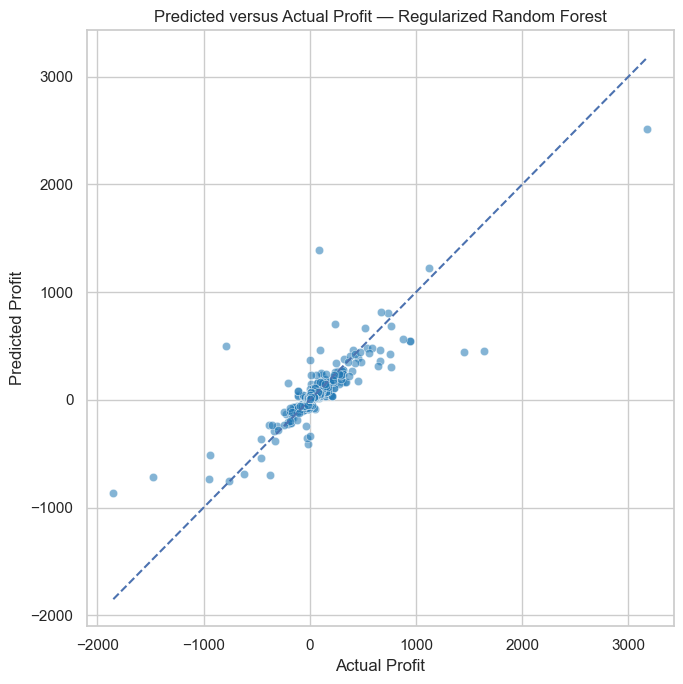

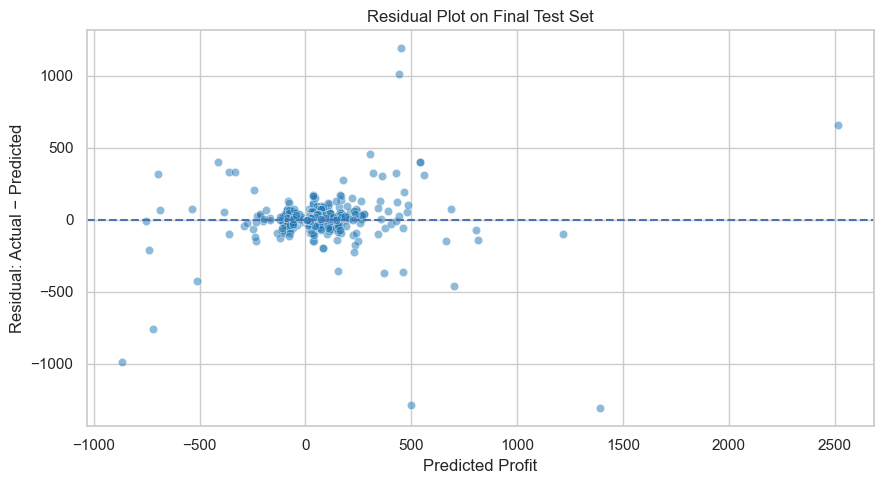

In [30]:
y_test_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.55, color='tab:blue')
plot_min = min(y_test.min(), y_test_pred.min())
plot_max = max(y_test.max(), y_test_pred.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], linestyle='--')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title(f'Predicted versus Actual Profit — {best_model_name}')
plt.tight_layout()
plt.show()

residuals = y_test - y_test_pred
plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.5, color='tab:blue')
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Profit')
plt.ylabel('Residual: Actual − Predicted')
plt.title('Residual Plot on Final Test Set')
plt.tight_layout()
plt.show()

## 14. Learning curves

Converging training and cross-validation MAE curves indicate that model variance is being controlled.

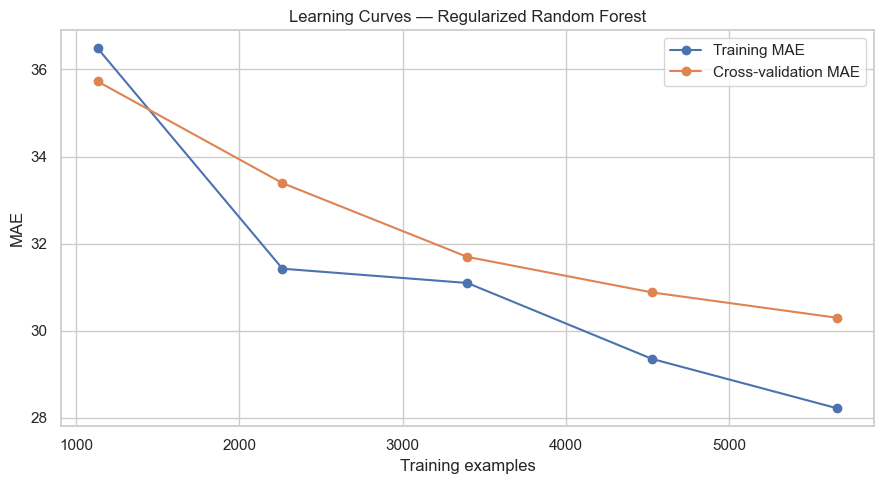

,Training examples,Training MAE,Cross-validation MAE,MAE gap
0,1132,36.4837,35.7241,-0.7596
1,2264,31.4231,33.3895,1.9664
2,3397,31.0952,31.6939,0.5987
3,4529,29.3503,30.8779,1.5276
4,5662,28.2174,30.2965,2.0791


In [31]:
learning_cv = list(
    StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    .split(X_dev, bins_dev)
)

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=clone(best_model),
    X=X_dev,
    y=y_dev,
    train_sizes=np.linspace(0.20, 1.00, 5),
    cv=learning_cv,
    scoring='neg_mean_absolute_error',
    n_jobs=2,
)

train_mae_curve = -train_scores.mean(axis=1)
validation_mae_curve = -validation_scores.mean(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mae_curve, marker='o', label='Training MAE')
plt.plot(train_sizes, validation_mae_curve, marker='o', label='Cross-validation MAE')
plt.xlabel('Training examples')
plt.ylabel('MAE')
plt.title(f'Learning Curves — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

learning_curve_table = pd.DataFrame({
    'Training examples': train_sizes,
    'Training MAE': train_mae_curve,
    'Cross-validation MAE': validation_mae_curve,
    'MAE gap': validation_mae_curve - train_mae_curve,
})
display(learning_curve_table)

## 15. Permutation feature importance

,Feature,Importance,Standard deviation
5,NetSales,27.4648,0.5445
4,DiscountAmount,10.2851,0.2824
1,Discount,8.6549,0.4908
6,LogSales,7.7687,0.3345
0,Sales,7.6184,0.2555
7,HighDiscount,4.0327,0.2369
2,Category,1.2205,0.1688
3,Region,0.0967,0.0311


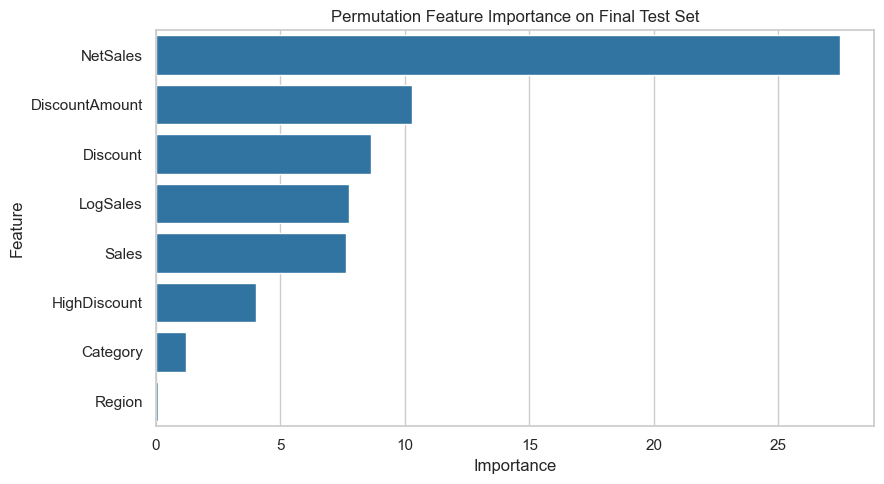

In [32]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=2,
)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': permutation.importances_mean,
    'Standard deviation': permutation.importances_std,
}).sort_values('Importance', ascending=False)

display(importance_df)
plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='tab:blue')
plt.title('Permutation Feature Importance on Final Test Set')
plt.tight_layout()
plt.show()

## 16. Business insights

In [33]:
category_business = (
    df.groupby('Category')
      .agg(
          Total_Sales=('Sales', 'sum'),
          Total_Profit=('Profit', 'sum'),
          Average_Profit=('Profit', 'mean'),
          Average_Discount=('Discount', 'mean'),
          Loss_Rate=('Profit', lambda s: (s < 0).mean()),
      )
      .sort_values('Total_Profit')
)
display(category_business)
print(f'Least profitable category: {category_business.index[0]}')

,Total_Sales,Total_Profit,Average_Profit,Average_Discount,Loss_Rate
Category,,,,,
Furniture,"741,999.7953","18,451.2728",8.6993,0.1739,0.3366
Office Supplies,"719,047.0320","122,490.8008",20.3270,0.1573,0.1470
Technology,"836,154.0330","145,454.9481",78.7520,0.1323,0.1467


Least profitable category: Furniture


In [34]:
df['DiscountBand'] = pd.cut(
    df['Discount'],
    bins=[-0.001, 0.00, 0.10, 0.20, 0.30, 0.40, 1.00],
    labels=['0%', '1–10%', '11–20%', '21–30%', '31–40%', '>40%'],
)

discount_summary = (
    df.groupby('DiscountBand', observed=False)
      .agg(
          Order_Lines=('Profit', 'size'),
          Average_Profit=('Profit', 'mean'),
          Total_Profit=('Profit', 'sum'),
          Loss_Rate=('Profit', lambda s: (s < 0).mean()),
      )
)
display(discount_summary)

high_discount = df[df['Discount'] >= 0.40]
print(f'Order lines with Discount >= 40%: {len(high_discount):,}')
print(f'Average Profit at Discount >= 40%: ${high_discount.Profit.mean():,.2f}')
print(f'Loss rate at Discount >= 40%: {high_discount.Profit.lt(0).mean() * 100:.2f}%')

,Order_Lines,Average_Profit,Total_Profit,Loss_Rate
DiscountBand,,,,
0%,4798,66.9003,"320,987.6032",0.0000
1–10%,94,96.0551,"9,029.1770",0.0426
11–20%,3709,24.7388,"91,756.2975",0.1399
21–30%,227,-45.6796,"-10,369.2774",0.9163
31–40%,233,-109.2197,"-25,448.1881",0.8884
>40%,933,-106.7080,"-99,558.5905",1.0000


Order lines with Discount >= 40%: 1,139
Average Profit at Discount >= 40%: $-107.65
Loss rate at Discount >= 40%: 97.72%


### Discount recommendation

Use **20% as the routine discount ceiling**. Discounts above 20% should require a model-based profitability check and managerial approval; discounts of 40% or more should be exceptional.

## 17. Reusable prediction function

In [35]:
valid_categories = sorted(df['Category'].dropna().unique().tolist())
valid_regions = sorted(df['Region'].dropna().unique().tolist())

def predict_profit(sales, discount, category, region):
    """Return estimated order-line Profit from the selected model."""
    sales = float(sales)
    discount = float(discount)

    if sales < 0:
        raise ValueError('sales must be non-negative.')
    if not 0 <= discount <= 1:
        raise ValueError('discount must be between 0 and 1.')
    if category not in valid_categories:
        raise ValueError(f'category must be one of {valid_categories}.')
    if region not in valid_regions:
        raise ValueError(f'region must be one of {valid_regions}.')

    raw_order = pd.DataFrame([{
        'Sales': sales,
        'Discount': discount,
        'Category': category,
        'Region': region,
    }])
    model_input = engineer_features(raw_order)
    return float(best_model.predict(model_input)[0])

example_prediction = predict_profit(
    sales=500,
    discount=0.20,
    category='Technology',
    region='West',
)
print(f'Estimated Profit: ${example_prediction:,.2f}')

Estimated Profit: $47.44


## 18. Save model and result tables

In [36]:
OUTPUT_DIR = Path('superstore_model_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, OUTPUT_DIR / 'best_profit_model.joblib')
final_comparison.to_csv(OUTPUT_DIR / 'final_model_comparison.csv', index=False)
importance_df.to_csv(OUTPUT_DIR / 'permutation_feature_importance.csv', index=False)
discount_summary.to_csv(OUTPUT_DIR / 'discount_band_summary.csv')
category_business.to_csv(OUTPUT_DIR / 'category_profitability_summary.csv')
print(f'Saved outputs to: {OUTPUT_DIR.resolve()}')

Saved outputs to: C:\Code\supriya-superstore-sales-profit-analytics-capstone\notebooks\superstore_model_outputs


## 19. Optional Streamlit discount simulator

The following cell writes `streamlit_discount_simulator.py`. Run it with:

```bash
streamlit run streamlit_discount_simulator.py
```

In [37]:
streamlit_code = '''import joblib
import numpy as np
import pandas as pd
import streamlit as st

MODEL_PATH = "superstore_model_outputs/best_profit_model.joblib"
model = joblib.load(MODEL_PATH)

CATEGORIES = ["Furniture", "Office Supplies", "Technology"]
REGIONS = ["Central", "East", "South", "West"]

def engineer_features(data):
    data = data.copy()
    data["DiscountAmount"] = data["Sales"] * data["Discount"]
    data["NetSales"] = data["Sales"] * (1 - data["Discount"])
    data["LogSales"] = np.log1p(data["Sales"].clip(lower=0))
    data["HighDiscount"] = (data["Discount"] >= 0.30).astype(int)
    return data

st.title("Superstore Discount Simulator")
st.write("Estimate Profit before approving a discount.")

sales = st.number_input("Sales", min_value=0.0, value=500.0, step=10.0)
discount_percent = st.slider("Discount (%)", min_value=0, max_value=80, value=20)
category = st.selectbox("Category", CATEGORIES)
region = st.selectbox("Region", REGIONS)

if st.button("Predict Profit"):
    raw = pd.DataFrame([{
        "Sales": sales,
        "Discount": discount_percent / 100,
        "Category": category,
        "Region": region,
    }])
    prediction = model.predict(engineer_features(raw))[0]
    st.metric("Estimated Profit", f"${prediction:,.2f}")
    if prediction < 0:
        st.error("Warning: predicted loss-making order.")
    elif discount_percent > 20:
        st.warning("Predicted profitable, but discount exceeds the routine 20% ceiling.")
    else:
        st.success("Predicted profitable and within the routine discount ceiling.")
'''

Path('streamlit_discount_simulator.py').write_text(streamlit_code, encoding='utf-8')
print('Created streamlit_discount_simulator.py')

Created streamlit_discount_simulator.py


## 20. Final methodological note

No modelling procedure can guarantee that overfitting is impossible. This notebook controls and diagnoses it through independent data splits, cross-validation, Decision Tree pruning, Random Forest regularization, generalization-gap reporting, and learning curves.